Integrantes:
1.   Eitan Besa
2.   Claudio Duran
3.   Eugenio Astrosa



#Clustering K-means

En esta notebook vamos a explorar un metodo de clusterización visto en la clase teórica. El método de clusterización que veremos corresponde a la rama de ML de aprendizaje no supervisado donde la idea principal es encontrar grupos en los datos que sean similares a otros datos del mismo grupo y lo menos similar posible a datos en otros.

El método es el algoritmo de partición **K-Means**, que aplicaremos al dataset de caras Olivetti, para tratar de agrupar las fotos según la persona a la que se le sacó la foto.

In [2]:
# importamos las librerías usuales de python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importamos los algoritmos de clusterizacion a utilizar en esta notebook
from sklearn.cluster import KMeans                    # K-means

## [K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans)

El método de clusterización "K-Means" busca encontrar *k* clusters de modo tal que se minimice la varianza intra-cluster medida, usualmente, como el cuadrado de la distancia euclídea. Para ello el algoritmo empieza encontrando *k centroids* y le asigna a cada sample la etiqueta correspondiente a la del centroid más cercano. Una vez actualizadas las etiquetas de todas las samples, calcula la posición de los k centroids (como el promedio de las features de las samples de cada cluster) y vuelve a asignar etiquetas a cada sample de acuerdo a la distancia al centroid más cercano. Hace estos dos pasos hasta que no haya más cambios de etiqueta.

Debido a esta inicialización aleatoria de los k centroids el output del modelo puede variar al aplicarlo otra vez a la misma data. Por ello se repite este procedimiento n_init=10 veces y el output final es el que mejor resultado tuvo al minimizar la función objetivo (varianza intra-cluster).

### Clustering en el dataset de caras Olivett

El dataset consta de 10 fotos de 64*64 pixeles en escala de grises de 40 personas distintas (400 fotos en total). Cada sample (foto) importada es un vector de 4096 elementos, los cuales representan las filas de pixeles ordenadas de arriba hacia abajo de la foto. Es decir, los primeros 64 elementos corresponden a la fila superior de pixeles de la imagen y así sucesivamente.

In [40]:
from sklearn.datasets import fetch_olivetti_faces # para cargar el dataset de caras
data, targets = fetch_olivetti_faces(return_X_y = True) # cargamos las caras

print('Dimensión de los datos {}'.format(data.shape))

Dimensión de los datos (400, 4096)


Gráficamos las imágenes, pero de solo 2 dimensiones. Puede jugar con cuales dimensiones gráficar.

Text(0, 0.5, 'Segunda dimensión')

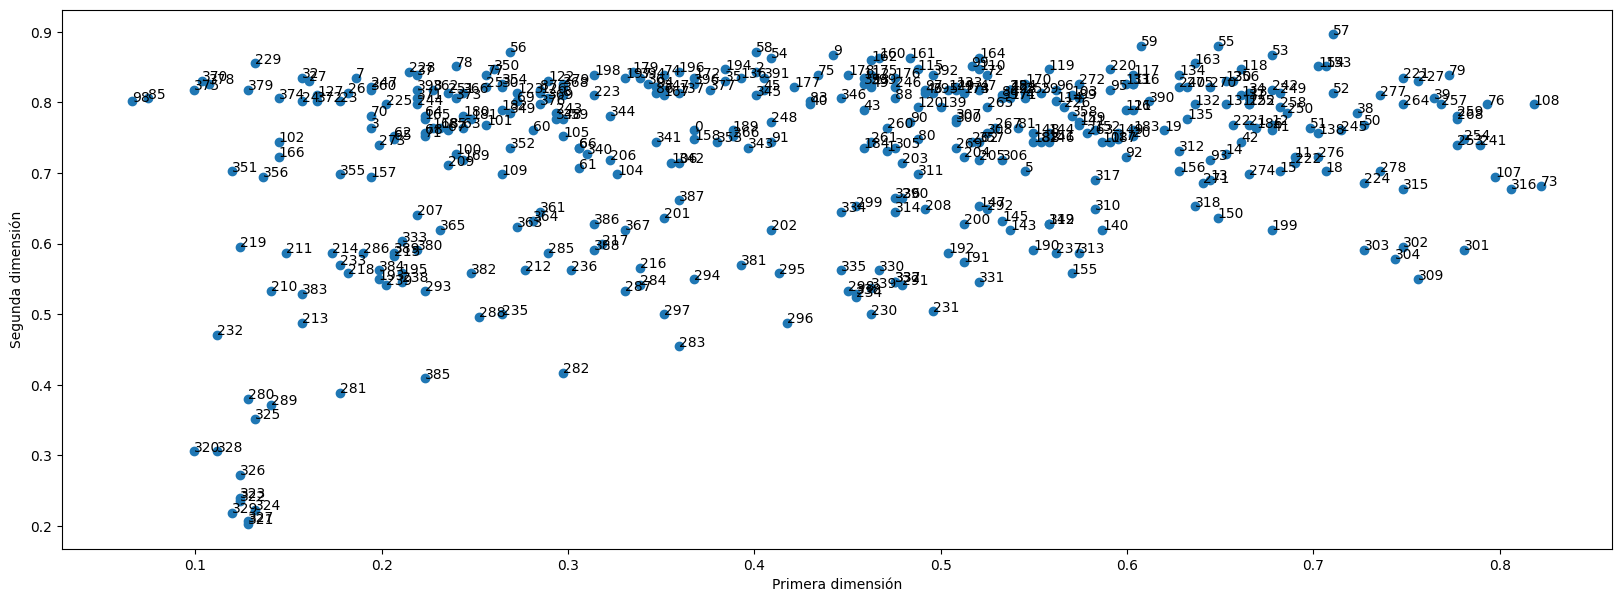

In [41]:
fig, ax = plt.subplots(figsize = (20, 7))

# dimensiones
d1 = 1
d2 = 30

# Hacemos un scatter plot de cada uno de los datos de las 2 primeras dimensiones
ax.scatter(data[:, d1], data[:, d2])

# Por cada dato escribimos a qué instancia corresponde
for i in range(data.shape[0]):
  ax.text(data[i, d1], data[i, d2], s = i)

ax.set_xlabel('Primera dimensión')
ax.set_ylabel('Segunda dimensión')

Ahora aplicamos el método de clusterización K-Means para agrupar las fotos en base a sus componentes principales. Como sabemos que el dataset consta de 40 personas diferentes utilizamos esta información para pedirle al algoritmo que encuentre k=40 clusters con la esperanza que podamos agrupar las fotos según la persona que está en ella.

In [5]:
# Creación del modelo KMeans con k = 40
kmeans = KMeans(n_clusters=40)

# Ajuste del modelo a los datos reducidos en componentes principales
kmeans.fit(data)

KMeans(n_clusters=40)

Para acceder a las etiquetas que le asignó el modelo a cada sample usamos 'kmeans.labels_'

In [6]:
# Nos fijamos las etiquetas asignadas a las primeras 10 muestras y los counts que recibió cada una
np.unique(kmeans.labels_[:10], return_counts=True)

(array([16, 22, 25, 28, 29, 39]), array([1, 2, 1, 1, 4, 1], dtype=int64))

Idealmente queríamos tener una sola etiqueta en las primeras 10 muestras ya que corresponden a las fotos tomadas a una persona. Sin embargo obtuvimos 5 etiquetas distintas.  **Esto dependerá que cuales dimensiones analizamos**

Veamos qué es lo que está pasando. Vamos a plotear el dataset, pero además vamos a asignarle un color a cada sample que corresponde a la etiqueta asignada por el modelo. También vamos a graficar con una "X" el centroid de cada cluster.

Para acceder a la posición de los centroids en el espacio de 100 PCs usamos 'kmeans.cluster_centers_'

In [7]:
# Guardo las posiciones de los centroids
centroids = kmeans.cluster_centers_

# Muestro las dimensiones de las posiciones
print("Shape de los centroids:",centroids.shape)
# Printeo las posiciones de las primeras 5 muestras en sus primeras dos componentes principales
print(centroids[:5,[d1,d2]])

Shape de los centroids: (40, 4096)
[[0.6608127  0.7899449 ]
 [0.24196512 0.8195592 ]
 [0.36336088 0.7245179 ]
 [0.60227275 0.802686  ]
 [0.2638271  0.6392244 ]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Segunda dimensión')

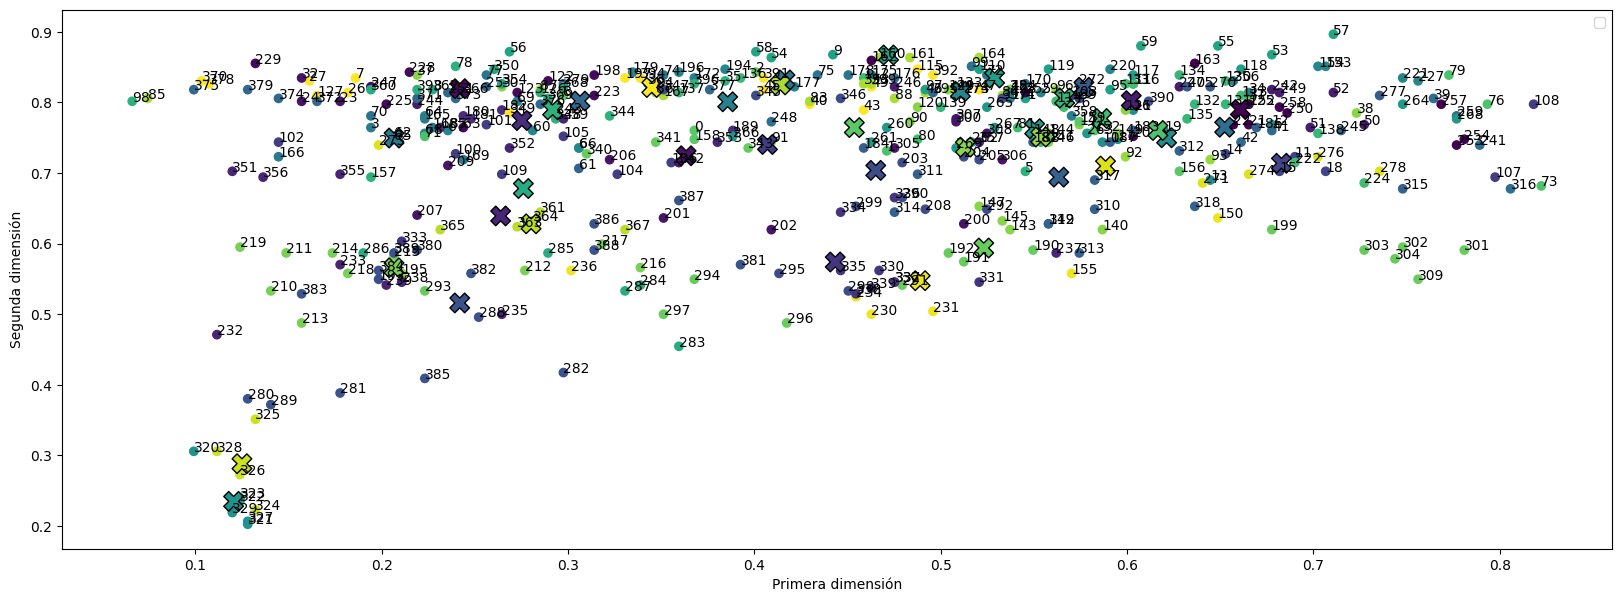

In [8]:
# Este bloque es similar al anterior pero agregando color a cada sample en el scatter plot según la etiqueta asignada

fig, ax = plt.subplots(figsize = (20, 7))


# Hacemos un scatter plot de cada uno de los datos
ax.scatter(data[:, d1], data[:, d2], c=kmeans.labels_)
ax.scatter(centroids[:, d1], centroids[:, d2], marker="X", s=200, linewidths=1,
            c=np.unique(kmeans.labels_), edgecolors='black')
ax.legend()

## Por cada dato escribimos a qué instancia corresponde. Pueden comentar estas 2 lineas para ver mejor los colores
for i in range(data.shape[0]):
  ax.text(data[i, d1], data[i, d2], s = i)

ax.set_xlabel('Primera dimensión')
ax.set_ylabel('Segunda dimensión')

En este plot podemos ver que hay samples más alejados de la nube principal de puntos que tienen un color definido.

Dependiendo de las variables graficadas, la distribución podria ser diferente. Pruebe graficando otras dimensiones

Parecería ser que los clusters que encuentra no son los que queríamos que nos diera el modelo. Pero entonces, ¿qué son estos clusters? Mostremos las imágenes correspondientes a cada cluster.

In [ ]:
# Mostrar el resultado final
labels = kmeans.labels_

# Iniciamos un for con k=40 iteraciones
for i in range(40):
    index = np.nonzero(labels==i)[0]                                    # los índices correspondientes a la i-ésima etiqueta
    num = len(index)                                                    # el número de samples en cada cluster
    this_faces = data[index].reshape(len(index),64,64)                  # reshapeamos los samples del i-ésimo cluster para que tenga el formato de una imagen de (64,64) pixeles
    fig, axes = plt.subplots(1, num, figsize=(24, 4),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    fig.suptitle("Cluster " + str(i), fontsize=20)
    for i, ax in enumerate(axes.flat):
        ax.imshow(this_faces[i], cmap='bone')

Podemos ver que varios clusters son imágenes de una sola persona, lo cual esta muy bien. Pero en otros casos, no agrupa bien.

Revise los cluster y vea las similitudes.

A pesar de que en los primeros gráficos no se apreciaba una buena clusterización, pudimso ver que varios clusters si tienen imágenes de una misma persona.

#### [Método del codo](https://en.wikipedia.org/wiki/Elbow_method_(clustering)#:~:text=In%20cluster%20analysis%2C%20the%20elbow,number%20of%20clusters%20to%20use.)

Se hace un grafico de la función objetivo en función de la elección de k y se elige el k correspondiente al punto donde agregar un cluster más no baja significativamente el valor que queremos minimzar. Esto se puede detectar a ojo o utilizando algún paquete de python como ['kneed'](https://raghavan.usc.edu//papers/kneedle-simplex11.pdf)

In [10]:
from kneed import KneeLocator # importamos el paquete para detectar el codo

Vamos a aplicar el método KMeans al dataset de caras pero cambiando el número de clusters k y guardaremos el puntaje de la función objetivo, SSE (suma de los cuadrados de la distancia euclidea de cada cluster), en una lista

In [11]:
# esto puede demorar un par de minutos

sse = [] # acá vamos a guardar el puntaje de la función objetivo

for k in range(1, 40):
  print(k)
  kkmeans = KMeans(n_clusters=k)
  kkmeans.fit(data)
  sse.append(kkmeans.inertia_)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


Vamos a graficar SEE en función del número de clusters k



Text(0, 0.5, 'SSE')

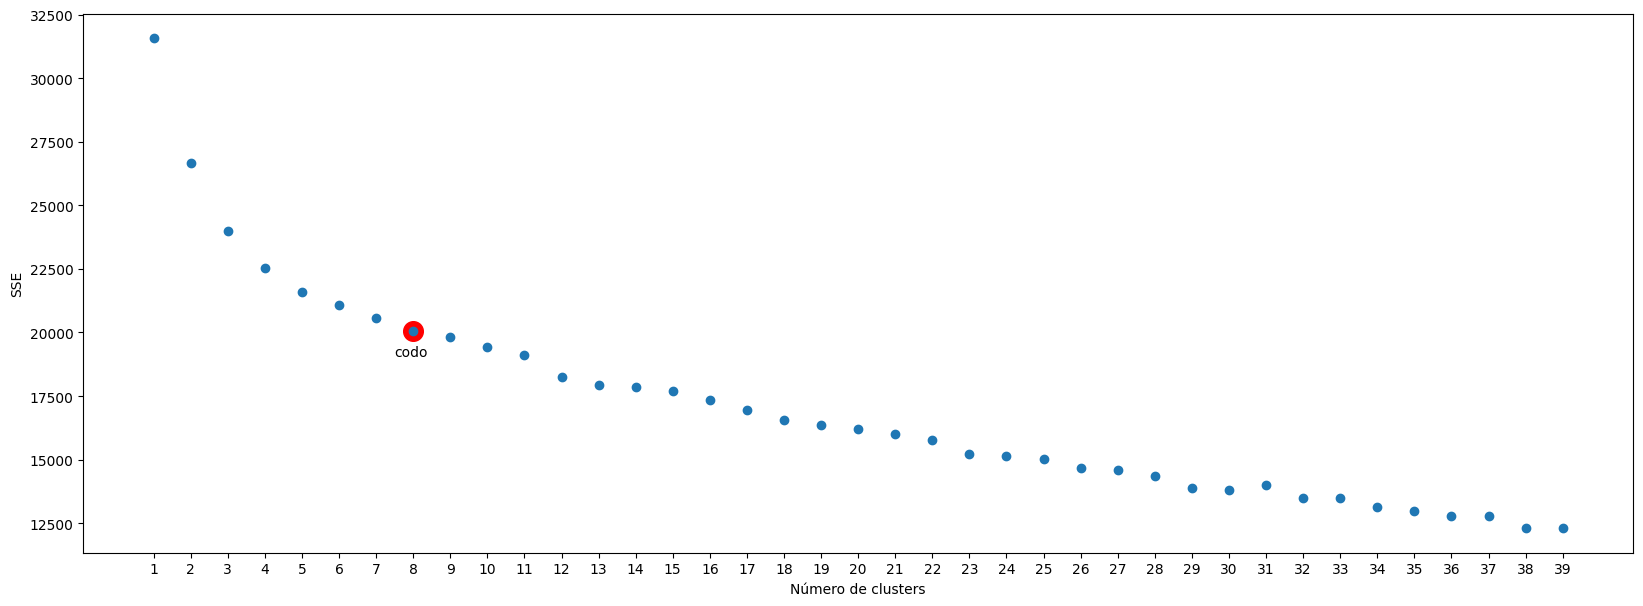

In [12]:
fig, ax = plt.subplots(figsize = (20, 7))

# esta dos lineas las agrego para que se vea la elección de KneeLocator para el codo en este gráfico
ax.scatter(8, sse[7], color='red', s=200) # agregamos un punto rojo al plot de tamaño s=200 en el lugar donde se encuentra el codo
ax.text(7.5, sse[7]-1000, s="codo")       # agregamos un texto abajo para indicar qué representa el punto

# estas lineas son el grafico de SSEvsK
ax.scatter(range(1, 40), sse)
ax.set_xticks(range(1, 40))
ax.set_xlabel("Número de clusters")
ax.set_ylabel("SSE")

En este plot podemos ver dos cosas:
1. SSE es monótonamente decreciente: al agregar un cluster la distancia entre todas las samples a los centroides siempre va a reducirse
2. A ojo distinguimos un codo entre k=7 y k=16 porque al agregar más clusters aumentamos la complejidad del modelo pero SEE disminuye en menor proporción.

Aun así, es muy dificil detectar el codo exactamente con la gráfica. No son muchos los casos donde con un gráfico podamos detectar el codo facilmente.

Usamos la función 'KneeLocator' para detectar el codo. Para ello le tenemos que pasar los valores de K, SEE, la forma de la fución (cóncava o convexa) y la dirección (creciente o decreciente)

In [13]:
from kneed import KneeLocator 

In [14]:
kl = KneeLocator(range(1, 40), sse, curve="convex", direction="decreasing")

print("El codo está en k =", kl.elbow)

El codo está en k = 7


## Resumen de funciones utilizadas e importantes.

KMeans

```
from sklearn.cluster import KMeans  # Importamos la clase KMeans

kmeans = KMeans(n_clusters=k)       # Crear el modelo con k-clusters

kmeans.fit(datos)                   # Ajustar el modelo a los datos

labels = kmeans.labels_             # Obtener las etiquetas de los k clusters para cada sample

centroids = kmeans.cluster_centers_ # Obtener las posiciones en el espacio de features del centro de los k clusters

sse = kmeans.inertia_               # Para obtener el valor de la función objetivo
```

Elección de k (si no lo conocemos de antemano):

Método del codo

```
!pip install kneed            # Instalamos el paquete kneed con pip install

from kneed import KneeLocator # Importamos la clase para detectar el codo

kl = KneeLocator(range(1, 40), sse, curve="convex", direction="decreasing") # Clase que sirve para calcular el codo en un gráfico de la función objetivo. Se le dan los puntos de la función con sus respectivos k, el tipo de curva (convexa o cóncava) y el sentido (creciente o decreciente)

kl.elbow                      # Devuelve el valor del codo
```

In [15]:
from sklearn.cluster import KMeans, AffinityPropagation
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(n_clusters=k, init='k-means++', random_state=1)

kmeans.fit(data)

labels = kmeans.labels_

centroids = kmeans.cluster_centers_

sse = kmeans.inertia_

print(sse)

12551.0712890625


In [16]:
# Ensure sse is initialized and empty before the loop
sse = []

for k in range(1, 40):
    print(k)
    kkmeans = KMeans(n_clusters=k, init='k-means++', random_state=1)
    kkmeans.fit(data)
    sse.append(kkmeans.inertia_)  # Add the inertia for this k to sse

# Now use KneeLocator
kl = KneeLocator(range(1, 40), sse, curve="convex", direction="decreasing")
print("El codo está en k =", kl.elbow)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
El codo está en k = 8


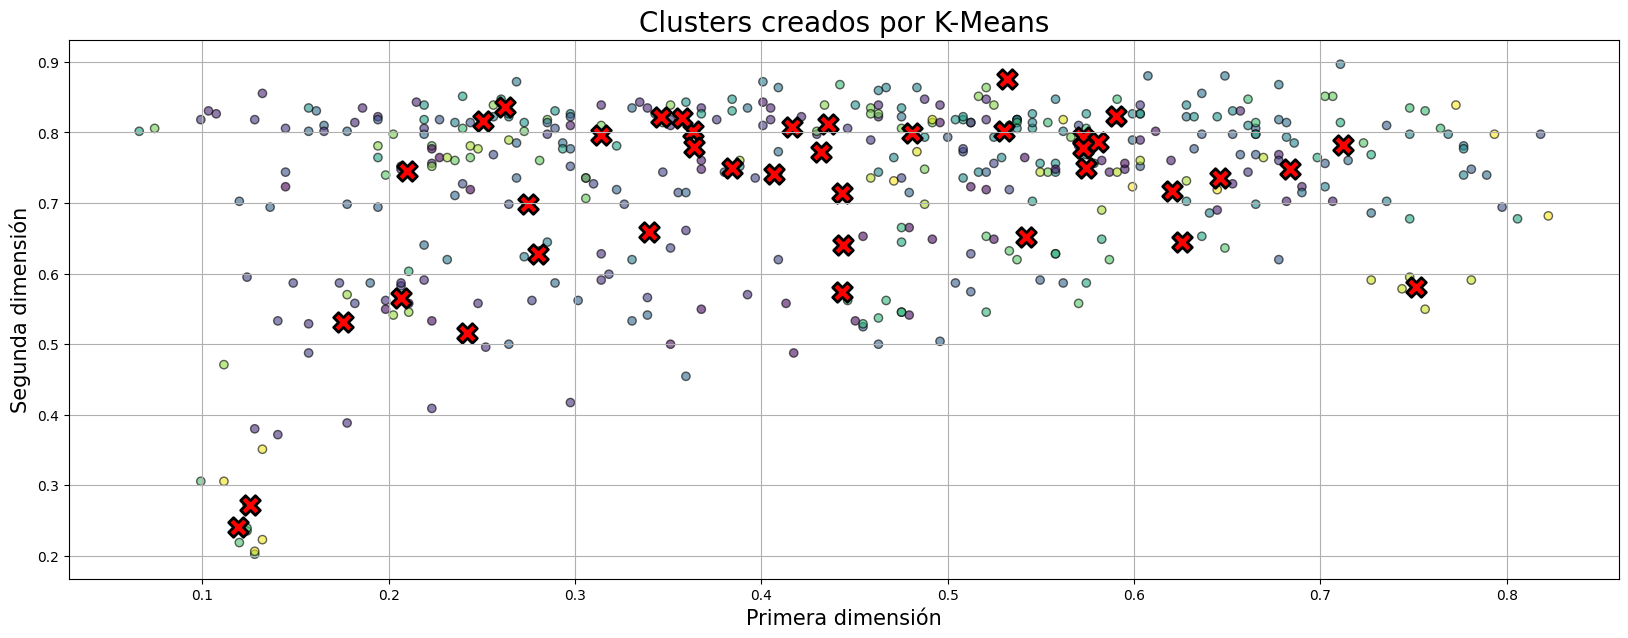

In [17]:
# Mejora en el gráfico de dispersión con KMeans
fig, ax = plt.subplots(figsize=(20, 7))

ax.scatter(data[:, d1], data[:, d2], c=kmeans.labels_, cmap='viridis', alpha=0.6, edgecolor='k')
ax.scatter(centroids[:, d1], centroids[:, d2], marker='X', s=200, linewidths=2, c='red', edgecolors='black')

# Mejorar títulos y etiquetas
ax.set_title('Clusters creados por K-Means', fontsize=20)
ax.set_xlabel('Primera dimensión', fontsize=15)
ax.set_ylabel('Segunda dimensión', fontsize=15)
ax.grid(True)
plt.show()


Codigo Git hub

In [18]:
# silhouette_score -> entre más alto mejor
# davies_bouldin_score -> entre más bajo mejor

# Clusters con el algoritmo K-Means (K-medias)
clusters_km = KMeans(n_clusters=4, random_state=1)
clusters_km.fit_predict(data)

# Cálculo de métricas para K-Means
silueta_km = silhouette_score(data, clusters_km.labels_)
davies_bouldin_km = davies_bouldin_score(data, clusters_km.labels_)

# Clusters con el algoritmo de Propagación de Afinidad
clusters_ap = AffinityPropagation(random_state=1)
clusters_ap.fit_predict(data)

# Cálculo de métricas para Propagación de Afinidad
silueta_ap = silhouette_score(data, clusters_ap.labels_)
davies_bouldin_ap = davies_bouldin_score(data, clusters_ap.labels_)


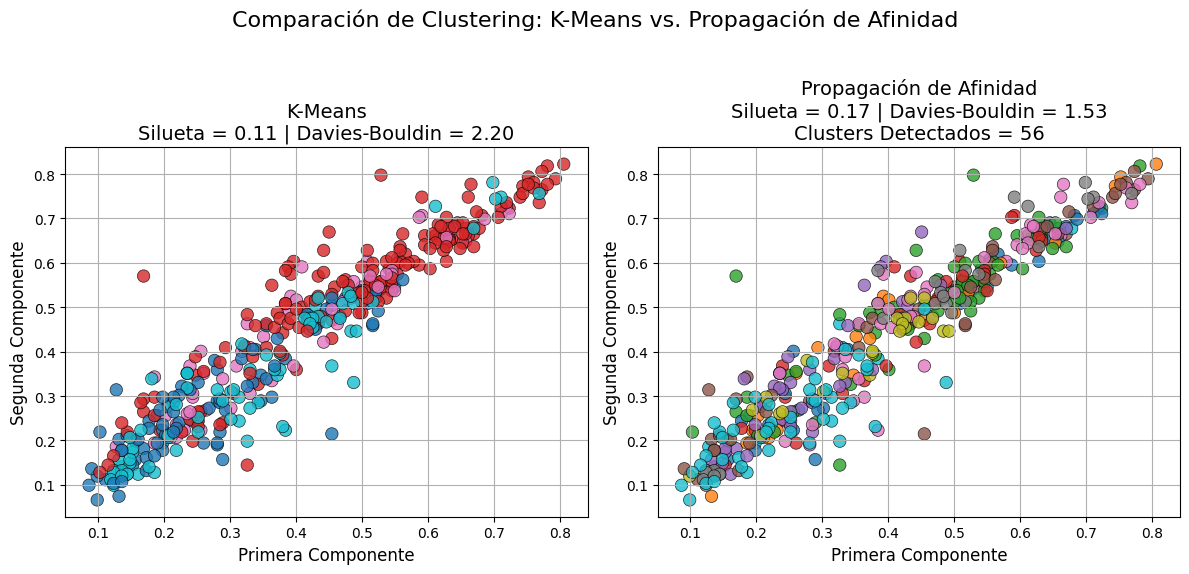

In [19]:
# Graficando los resultados
fig = plt.figure(figsize=(12, 6))
fig.suptitle('Comparación de Clustering: K-Means vs. Propagación de Afinidad', fontsize=16)
plt.set_cmap("tab10")  # Mejorar la paleta de colores

# Gráfica de clusters con K-Means
ax = fig.add_subplot(1, 2, 1)
ax.scatter(data[clusters_km.labels_ >= 0][:, 0], data[clusters_km.labels_ >= 0][:, 1],
           c=clusters_km.labels_[clusters_km.labels_ >= 0], cmap='tab10', s=80,
           linewidth=0.5, edgecolors="black", alpha=0.8)
ax.set_title(f"K-Means\nSilueta = {silueta_km:.2f} | Davies-Bouldin = {davies_bouldin_km:.2f}", fontsize=14)
ax.set_xlabel('Primera Componente', fontsize=12)
ax.set_ylabel('Segunda Componente', fontsize=12)
ax.grid(True)

# Gráfica de clusters con Propagación de Afinidad
ax = fig.add_subplot(1, 2, 2)
ax.scatter(data[clusters_ap.labels_ >= 0][:, 0], data[clusters_ap.labels_ >= 0][:, 1],
           c=clusters_ap.labels_[clusters_ap.labels_ >= 0], cmap='tab10', s=80,
           linewidth=0.5, edgecolors="black", alpha=0.8)
ax.set_title(f"Propagación de Afinidad\nSilueta = {silueta_ap:.2f} | Davies-Bouldin = {davies_bouldin_ap:.2f}\nClusters Detectados = {len(np.unique(clusters_ap.labels_))}", fontsize=14)
ax.set_xlabel('Primera Componente', fontsize=12)
ax.set_ylabel('Segunda Componente', fontsize=12)
ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Como se puede observar en el grafico de comparación de K-Means vs Propagación de afinidad el grafico de propagación de afinidad muestra una estructura mas compacta y mejor definida ya que tiene
#una silueta de 0.17 lo que significa que en comparación al K-means esta tiene mas cohesion en su cluster. Ademas de que el Davies-bouldin de 1.53 que en comparación al K-Means de 2.20 este esta mas cercano a 0 y por
ende tiene una mejor clusterización que ek K-Means.


### Codigo Github


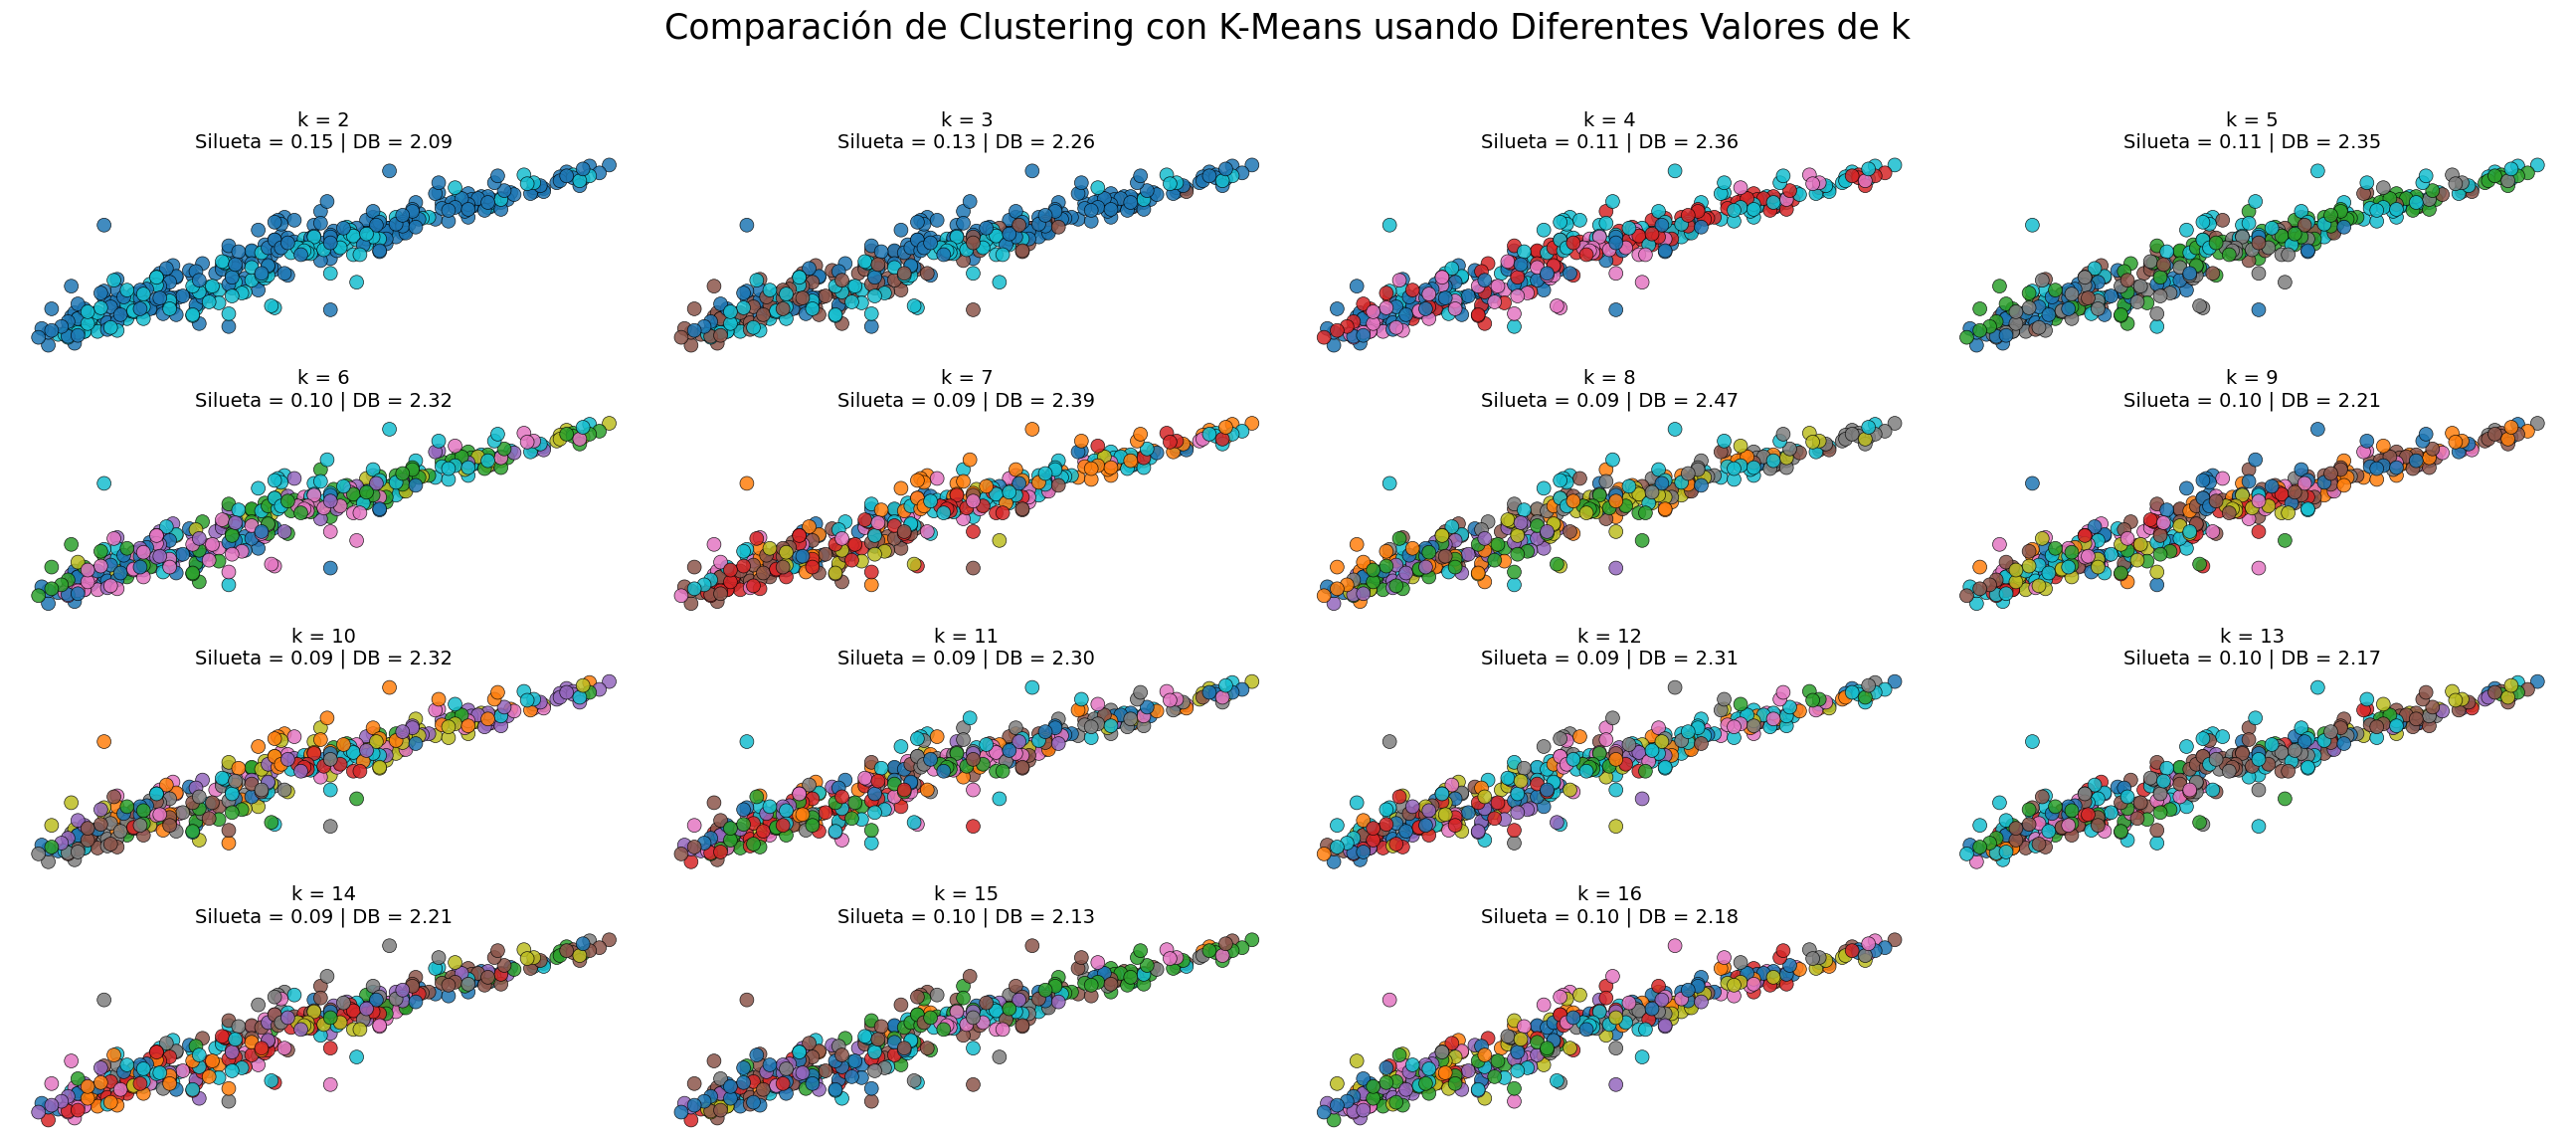

In [20]:
# Crear figura para la comparación
fig = plt.figure(figsize=(26, 12))
fig.suptitle('Comparación de Clustering con K-Means usando Diferentes Valores de k', fontsize=25)

for k in range(2, 17):
    # Creación de clusters con K-Means
    clusters = KMeans(n_clusters=k, init='k-means++', random_state=1, n_init=10)
    clusters.fit_predict(data)

    # Cálculo de métricas
    silueta = silhouette_score(data, clusters.labels_)
    davies_bouldin = davies_bouldin_score(data, clusters.labels_)

    # Graficando clusters
    ax = fig.add_subplot(4, 4, k-1)  # 4 filas y 4 columnas para acomodar los 15 gráficos
    ax.scatter(data[clusters.labels_ >= 0][:, 0], data[clusters.labels_ >= 0][:, 1],
               c=clusters.labels_[clusters.labels_ >= 0], cmap='tab10', s=100,
               linewidth=0.5, edgecolors="black", alpha=0.85)
    ax.set_title(f'k = {k}\nSilueta = {silueta:.2f} | DB = {davies_bouldin:.2f}', fontsize=14)
    ax.axis("off")
    ax.grid(True)

# Ajustar el layout para que los gráficos no se solapen
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

En esta comparación de Clustering con K-Means el mejor clouster es el que tiene 2 ya que tiene la Silueta mas elevada y el Davies-Bouldin mas bajo de todos los clouster presentes y esto significa
que la comparación del clouster 2 (k=2) es la que tiene mejor agrupado os datos y tienen  mejor cohesión y por el lado del Davies-Bouldin significa que los clouster estan separados y eso evita o minimiza la confusion de estos.

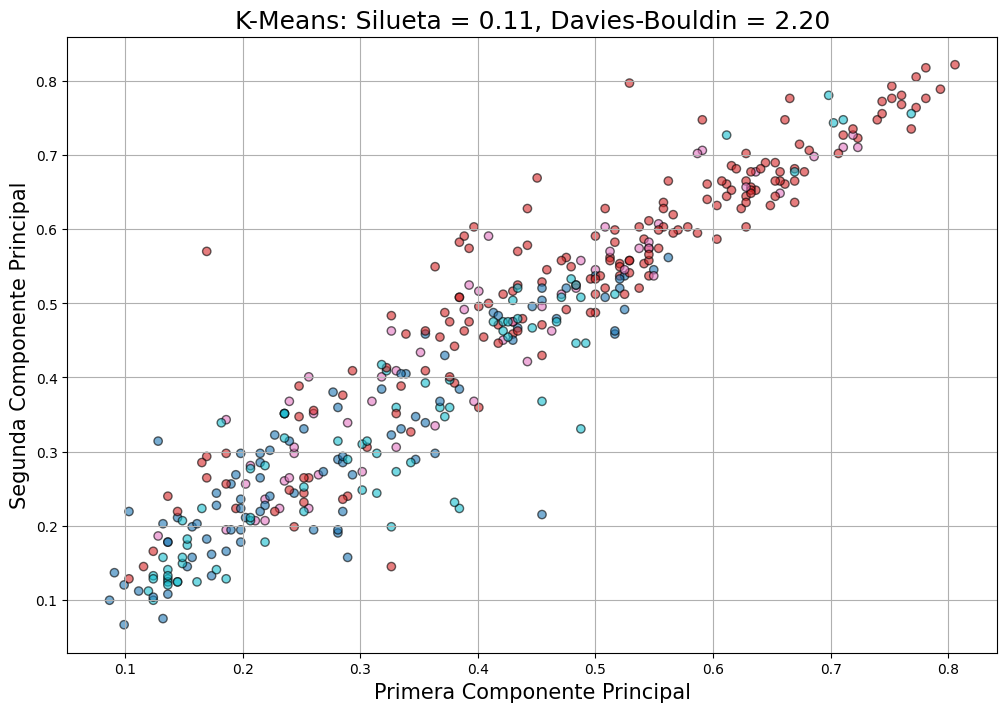

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(data[:, 0], data[:, 1], c=clusters_km.labels_, cmap='tab10', alpha=0.6, edgecolor='k')
ax.set_title(f'K-Means: Silueta = {silueta_km:.2f}, Davies-Bouldin = {davies_bouldin_km:.2f}', fontsize=18)
ax.set_xlabel('Primera Componente Principal', fontsize=15)
ax.set_ylabel('Segunda Componente Principal', fontsize=15)
ax.grid(True)
plt.show()


Este gráfico muestra que los datos han sido divididos en clusters, con un valor de Silueta de 0.11, sugiere que los clusters no están bien definidos y se encuentran  mal agrupados.
Y con un valor de 2.20 de la metrica Davies tambien sugiere que los clusters no están bien separados y se pueden superponer entre si.

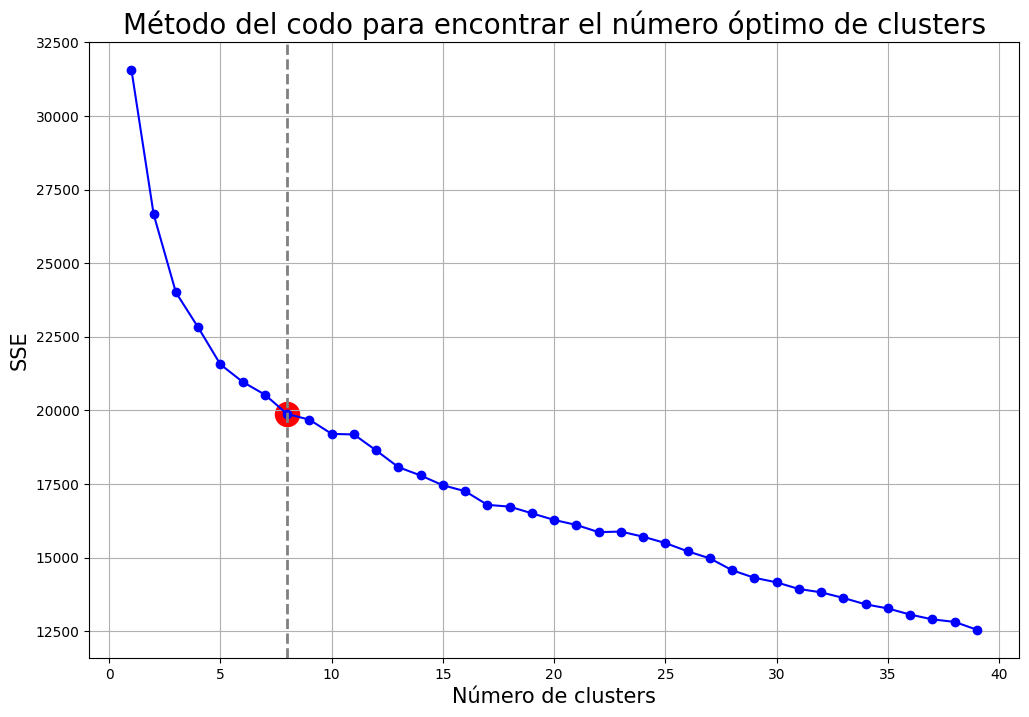

El mejor valor de k según el método del codo es: 8


In [22]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(range(1, 40), sse, '-o', color='blue')
ax.scatter(kl.elbow, sse[kl.elbow - 1], s=300, color='red')
ax.axvline(kl.elbow, linestyle='--', color='gray', linewidth=2)
ax.set_title('Método del codo para encontrar el número óptimo de clusters', fontsize=20)
ax.set_xlabel('Número de clusters', fontsize=15)
ax.set_ylabel('SSE', fontsize=15)
ax.grid(True)
plt.show()

print("El mejor valor de k según el método del codo es:", kl.elbow)

Segun el metodo del codo este infiere que el mejor valor o clouster es 8 pero en la comparación que se muestra mas arriba se muestra que el mejor clouster utilizando K-Means
es el k=2 ya que tiene una silueta mas elevada y un Davies-Bouldin mas bajo que los demas clousters por ende lo hace mas especifico ya que es el que tiene mas definido y separado su conjunto de datos.

# Clustering Jerarquico

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.datasets import make_blobs
import scipy.cluster.hierarchy as shc

In [43]:
from sklearn.datasets import fetch_olivetti_faces # para cargar el dataset de caras
data, targets = fetch_olivetti_faces(return_X_y = True) # cargamos las caras

print('Dimensión de los datos {}'.format(data.shape))

Dimensión de los datos (400, 4096)


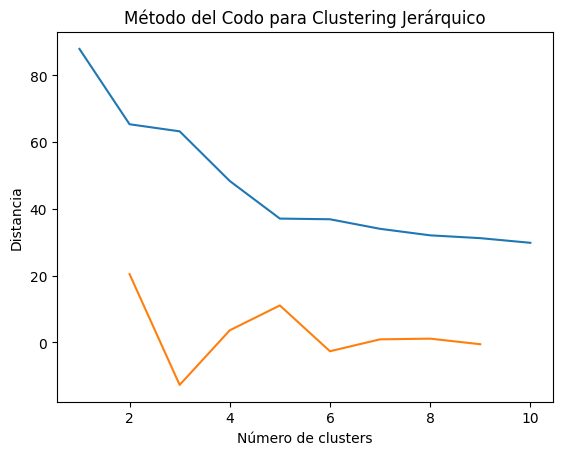

El número óptimo de clusters es: 2


In [44]:
# Calcular la matriz de distancias
dist_matrix = pdist(data)

# Aplicar el algoritmo de clustering jerárquico
Z = linkage(dist_matrix, 'ward')

# Método del Codo
last = Z[-10:, 2]
last_rev = last[::-1]
idxs = np.arange(1, len(last) + 1)
plt.plot(idxs, last_rev)

# Aumentos en las distancias
acceleration = np.diff(last, 2)  # Segunda derivada de las distancias
acceleration_rev = acceleration[::-1]
plt.plot(idxs[:-2] + 1, acceleration_rev)
plt.xlabel('Número de clusters')
plt.ylabel('Distancia')
plt.title('Método del Codo para Clustering Jerárquico')
plt.show()

k = acceleration_rev.argmax() + 2  # Encontrar el punto del codo
print(f"El número óptimo de clusters es: {k}")


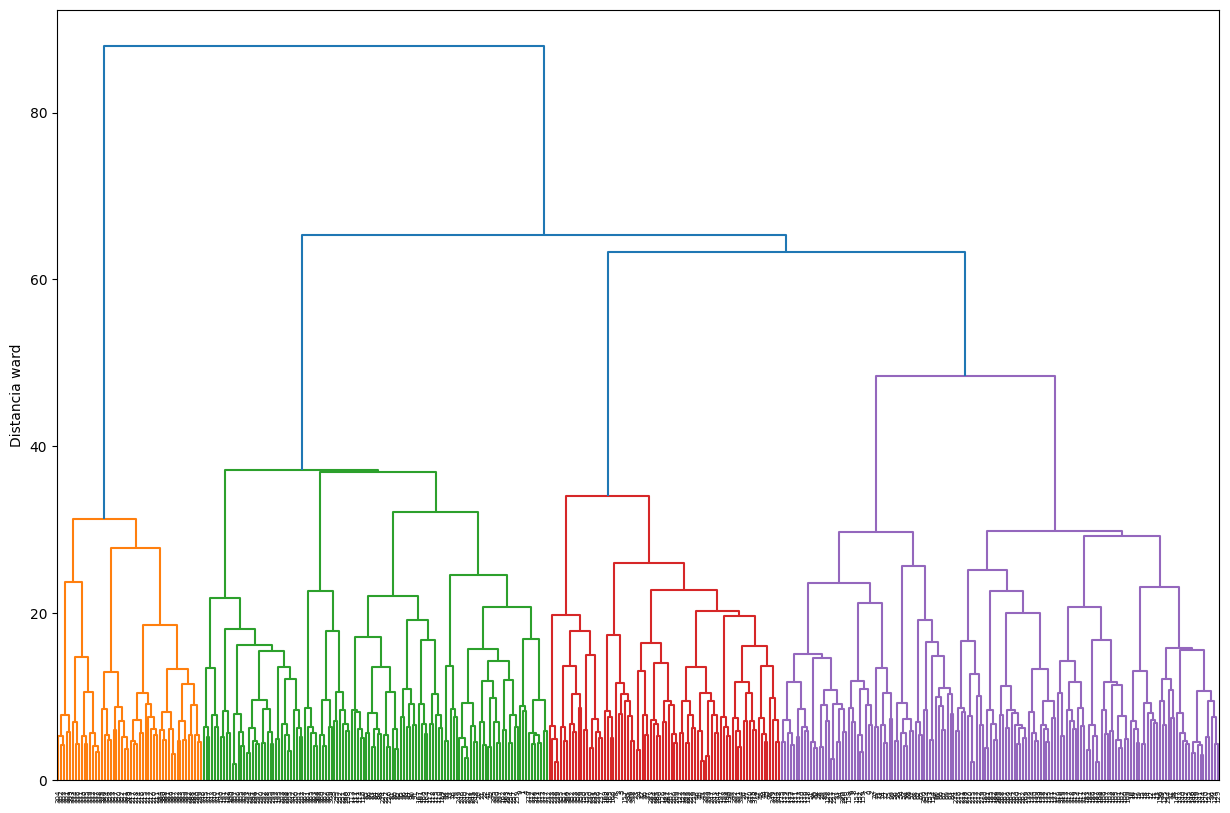

In [45]:
plt.figure(figsize=(15, 10))
plt.ylabel("Distancia ward")
dend = shc.dendrogram(shc.linkage(data, method='ward'))
plt.axhline(150, c='r')

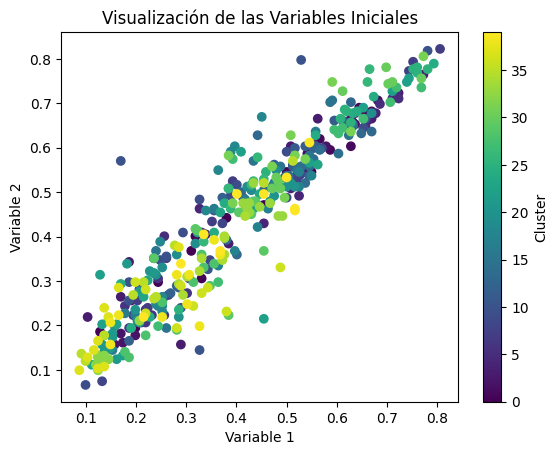

In [46]:
# Graficar los datos
plt.scatter(data[:, 0], data[:, 1], c= targets, cmap='viridis')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('Visualización de las Variables Iniciales')
plt.colorbar(label='Cluster')
plt.show()

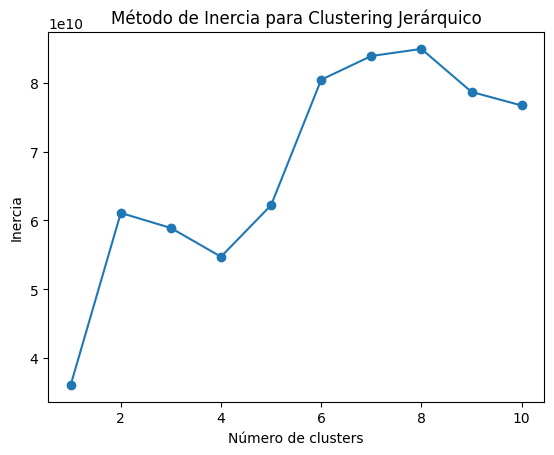

In [47]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances_argmin_min

# Función para calcular la inercia
def calculate_inertia(X, labels):
    centroids, _ = pairwise_distances_argmin_min(np.array([X[labels == i].mean(axis=0) for i in np.unique(labels)]), X)
    inertia = sum((X[i] - centroids[labels[i]]) ** 2 for i in range(X.shape[0]))
    return inertia.sum()

# Calcular la inercia para diferentes números de clusters
inertias = []
for n_clusters in range(1, 11):
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = model.fit_predict(data)
    inertia = calculate_inertia(data, labels)
    inertias.append(inertia)

# Graficar el método de inercia
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método de Inercia para Clustering Jerárquico')
plt.show()
